# 4. Categorical Naive Bayes

### Data Type

Categories.

### Example
- Sunny

- Rain

- Overcast

In [170]:
import math

# Training dataset
data = [
    ['Sunny', 'Hot', 'High', 'Weak', 'No'],
    ['Sunny', 'Hot', 'High', 'Strong', 'No'],
    ['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Strong', 'No'],
    ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
    ['Sunny', 'Mild', 'High', 'Weak', 'No']
]


In [171]:
# Get all possible classes
def get_classes(data):
    return list(set(row[-1] for row in data))

print(get_classes(data))

['Yes', 'No']


In [ ]:
# Count frequency of attribute values for each class
def summarize_by_class(data):
    summaries = {}
    classes = get_classes(data)
    for c in classes:
        # Take each row and store it in a list which have class = yes
        class_rows = [row for row in data if row[-1] == c]
        summaries[c] = {
            'total': len(class_rows),
            'features': {}
        }
    
        for col in range(len(data[0]) - 1):  # skip class column
            # for class_rows take the column
            values = [row[col] for row in class_rows]
            counts = {}
            for val in values:
                counts[val] = counts.get(val, 0) + 1
            summaries[c]['features'][col] = counts
    return summaries

In [173]:
# Calculate prior and likelihood probabilities
def calculate_class_probabilities(summaries, input_data):
    total_rows = sum(summaries[c]['total'] for c in summaries)
    probs = {}
    for c, stats in summaries.items():
        prob = stats['total'] / total_rows  # prior
        for i in range(len(input_data)):
            feature_counts = stats['features'].get(i, {})
            count = feature_counts.get(input_data[i], 0)
            prob *= (count + 1) / (stats['total'] + len(feature_counts))  # Laplace smoothing
            print(f"feautes {feature_counts} Count {count} prob {prob}")
        probs[c] = prob
        print("final probs for class :", probs)
    return probs

In [174]:
# Predict
def predict(summaries, input_data):
    probs = calculate_class_probabilities(summaries, input_data)
    return max(probs, key=probs.get)

In [175]:
# Train
summaries = summarize_by_class(data)
summaries

{'Yes': {'total': 4,
  'features': {0: {'Overcast': 2, 'Rain': 2},
   1: {'Hot': 1, 'Mild': 1, 'Cool': 2},
   2: {'High': 2, 'Normal': 2},
   3: {'Weak': 3, 'Strong': 1}}},
 'No': {'total': 4,
  'features': {0: {'Sunny': 3, 'Rain': 1},
   1: {'Hot': 2, 'Cool': 1, 'Mild': 1},
   2: {'High': 3, 'Normal': 1},
   3: {'Weak': 2, 'Strong': 2}}}}

In [ ]:

# Predict a new sample
test_sample = ['Rain', 'Mild', 'High', 'Strong']
prediction = predict(summaries, test_sample)
print(f"Prediction: {prediction}")

# 1+1 = 2
# / 3+4 = 7

feautes {'Overcast': 2, 'Rain': 2} Count 2 prob 0.25
feautes {'Hot': 1, 'Mild': 1, 'Cool': 2} Count 1 prob 0.07142857142857142
feautes {'High': 2, 'Normal': 2} Count 2 prob 0.03571428571428571
feautes {'Weak': 3, 'Strong': 1} Count 1 prob 0.011904761904761904
final probs for class : {'Yes': 0.011904761904761904}
feautes {'Sunny': 3, 'Rain': 1} Count 1 prob 0.16666666666666666
feautes {'Hot': 2, 'Cool': 1, 'Mild': 1} Count 1 prob 0.047619047619047616
feautes {'High': 3, 'Normal': 1} Count 3 prob 0.031746031746031744
feautes {'Weak': 2, 'Strong': 2} Count 2 prob 0.015873015873015872
final probs for class : {'Yes': 0.011904761904761904, 'No': 0.015873015873015872}
Prediction: No


# Naive Bayes Family

In [177]:
#                  Naive Bayes
#                       │
#      ┌────────────────┼─────────────────┐
#      │                │                 │
# Bernoulli NB     Multinomial NB   Gaussian NB
#      │                │                 │
#  Binary Data      Count Data      Continuous Data

# 1. Bernoulli Naive Bayes

### Data Type

Only binary features.

### Example

- 0 or 1

- Yes or No

- True or False

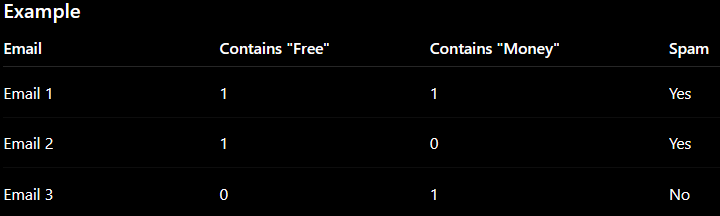

In [178]:
X = [
    [1, 1],   # Free, Money
    [1, 0],   # Free
    [0, 1],   # Money
    [0, 0],   # Neither
]

y = [
    "Spam",
    "Spam",
    "Ham",
    "Ham"
]

In [179]:
class BernoulliNaiveBayes:

    def __init__(self):
        self.classes = None
        self.priors = {}
        self.feature_probs = {}

    def fit(self, X, y):
        
        # get unique classes (y)
        self.classes = list(set(y))
        
        # total samples take x or y
        total_samples = len(y)

        # iter class
        for cls in self.classes:
            
            # find X for single cls
            X_cls = [X[i] for i in range(total_samples) if y[i] == cls] # iter X and check that index of y is equal to the cls if yes store in X_class
            
            # len of current cls
            total_X_cls = len(X_cls)

            # updating the current prior probability
            self.priors[cls] =  total_X_cls / total_samples

            # make a empty list for the current class
            self.feature_probs[cls] = []

            # Update the feature
            # len(X[0]) -> 2 columns
            for column in range(len(X[0])):
                
                counts = sum(row[column] for row in X_cls)
                # probs = counts / total_X_cls
                probs = counts + 1 / total_X_cls + 2
                
                self.feature_probs[cls].append(probs)

        print(self.feature_probs)

    def predict(self, X):
        scores = {}

        for cls in self.classes:

            prob = self.priors[cls]

            for j in range(len(X)):

                p = self.feature_probs[cls][j]

                if X[j] == 1:
                    prob *= p
                else:
                    prob *= (1 - p)

            scores[cls] = prob

            return max(scores, key = scores.get)

# Creating object for class
model = BernoulliNaiveBayes()

model.fit(X, y)

model.predict([1, 0])

{'Spam': [4.5, 3.5], 'Ham': [2.5, 3.5]}


'Spam'

# 2. Multinomial Naive Bayes

### Data Type

Counts.

| Word     | Count    |
| -------- | -------- |
| Free     | 3        |
| Money    | 5        |
| Win      | 2        |

Instead of Free = Yes

we store Free appeared 3 times.

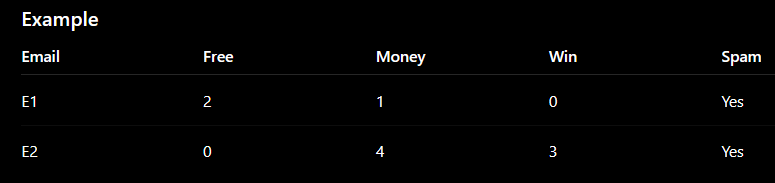

In [180]:
X = [
    [3,1,0],
    [2,0,1],
    [0,2,0],
    [0,1,2]
]

y = [
    "Spam",
    "Spam",
    "Ham",
    "Ham"
]

In [ ]:
class MultinomialNaiveBayes:

    def __init__(self):
        self.classes = None
        self.priors = {}
        self.word_probs = {}

    def fit(self, X, y):
        
        # get unique classes (y)
        self.classes = list(set(y))
        
        # total samples take x or y
        total_samples = len(y)

        n_feature = len(X[0])

        # iter class
        for cls in self.classes:
            
            # find X for single cls
            X_cls = [X[i] for i in range(total_samples) if y[i] == cls] # iter X and check that index of y is equal to the cls if yes store in X_class
            
            # len of current cls
            total_X_cls = len(X_cls)

            # updating the current prior probability
            self.priors[cls] =  total_X_cls / total_samples

            # changed from here
            words_counts = [0] * n_feature

            for row in X_cls:
                for j in range(n_feature):
                    words_counts[j] += row[j]

            total_words = sum(words_counts)

            self.word_probs[cls] = []

            for count in words_counts:
                probs = (count + 1) / (total_words + n_feature)
                self.word_probs[cls].append(probs)
        
        print(self.word_probs)

    def predict(self, X):
        scores = {}

        for cls in self.classes:

            prob = self.priors[cls]

            for j in range(len(X)):
                # changed from here
                prob *= self.word_probs[cls][j] ** X[j]

            scores[cls] = prob

        return max(scores, key = scores.get)

# Creating object for class
model = MultinomialNaiveBayes()

model.fit(X, y)

print(model.predict([2,1,2]))

{'Spam': [0.6, 0.2, 0.2], 'Ham': [0.125, 0.5, 0.375]}
Spam


# 3. Gaussian Naive Bayes

### Data Type

Continuous numbers.

### Example

- Age = 25

- Salary = 40000

- Height = 175 cm

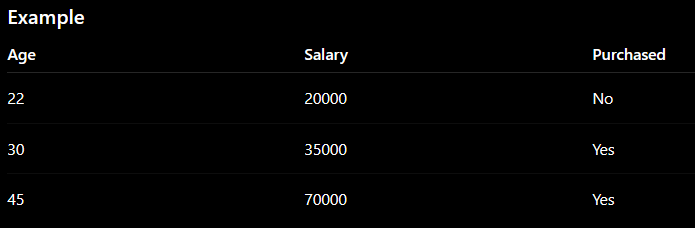

In [185]:
import math

class GaussianNaiveBayes:

    def __init__(self):
        self.classes = None
        self.priors = {}
        self.mean = {}
        self.var = {}

    def fit(self, X, y):

        self.classes = list(set(y))

        total_samples = len(y)
        n_features = len(X[0])

        for cls in self.classes:

            X_cls = [X[i] for i in range(total_samples) if y[i] == cls]

            total_cls = len(X_cls)

            self.priors[cls] = total_cls / total_samples

            self.mean[cls] = []
            self.var[cls] = []

            for j in range(n_features):

                values = [row[j] for row in X_cls]

                mean = sum(values) / len(values)

                variance = sum((x - mean) ** 2 for x in values) / len(values)

                self.mean[cls].append(mean)
                self.var[cls].append(variance)

    def gaussian(self, x, mean, var):

        if var == 0:
            var = 1e-9

        exponent = math.exp(-(x - mean) ** 2 / (2 * var))

        coefficient = 1 / math.sqrt(2 * math.pi * var)

        return coefficient * exponent

    def predict(self, sample):

        scores = {}

        for cls in self.classes:

            prob = self.priors[cls]

            for j in range(len(sample)):

                prob *= self.gaussian(
                    sample[j],
                    self.mean[cls][j],
                    self.var[cls][j]
                )

            scores[cls] = prob

        return max(scores, key=scores.get)
    

X = [
    [22, 25000],
    [25, 30000],
    [35, 60000],
    [40, 65000]
]

y = [
    "No",
    "No",
    "Yes",
    "Yes"
]

model = GaussianNaiveBayes()

model.fit(X, y)

print(model.predict([23, 27000]))
print(model.predict([38, 62000]))

No
Yes
